In [4]:
import pandas as pd

df = pd.read_excel("ALL.xlsx")

df.head()

,Item_ID,Item,Construct,Bloom_Level,Bloom Action Verbs,DoK_Level,Lexical Diversity,Avg Sentence Length,Readability
0,HiBloom_1,Anne had a password in her phone represented b...,Numbers,Analyse,"Analyze, Appraise, Break down, Categorize, Cla...",NaN,NaN,NaN,NaN
1,HiBloom_2,Musoke had two wives one in Kanginima village ...,Data and Probability,Evaluate,Appraise; Argue; Assess; Check; Conclude; Conf...,NaN,NaN,NaN,NaN
2,HiBloom_3,On the last Sunday of the holiday Your uncle d...,Numbers,Create,Adapt; Assemble; Combine; Compile; Compose; Co...,NaN,NaN,NaN,NaN
3,HiBloom_4,"During their baking lesson, the students were ...",Patterns and Algebra,Analyse,"Analyze, Appraise, Break down, Categorize, Cla...",NaN,NaN,NaN,NaN
4,HiBloom_5,A certain member of your family re-wrote each ...,Geometry and Measures,Evaluate,Appraise; Argue; Assess; Check; Conclude; Conf...,NaN,NaN,NaN,NaN


In [5]:
import re

def lexical_diversity(text):
    words = re.findall(r'\b\w+\b', str(text).lower())
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

df["Lexical Diversity"] = df["Item"].apply(lexical_diversity)

In [6]:
def avg_sentence_length(text):
    sentences = re.split(r'[.!?]+', str(text))
    sentences = [s for s in sentences if s.strip()]
    words = re.findall(r'\b\w+\b', str(text))
    
    if len(sentences) == 0:
        return 0
    
    return len(words) / len(sentences)

df["Avg Sentence Length"] = df["Item"].apply(avg_sentence_length)

In [7]:
%pip install textstat

Note: you may need to restart the kernel to use updated packages.


In [8]:
import textstat

df["Readability"] = df["Item"].apply(
    lambda x: textstat.flesch_reading_ease(str(x))
)

In [9]:
def assign_dok(bloom):
    bloom = str(bloom).lower()
    
    if bloom in ["remember"]:
        return 1
    elif bloom in ["understand", "apply"]:
        return 2
    elif bloom in ["analyze", "evaluate"]:
        return 3
    elif bloom in ["create"]:
        return 4
    else:
        return None

df["DoK_Level"] = df["Bloom_Level"].apply(assign_dok)

In [10]:
df.to_excel("ALL_with_features.xlsx", index=False)

In [11]:
import pandas as pd

df = pd.read_excel("ALL_with_features.xlsx")
df.head()

,Item_ID,Item,Construct,Bloom_Level,Bloom Action Verbs,DoK_Level,Lexical Diversity,Avg Sentence Length,Readability
0,HiBloom_1,Anne had a password in her phone represented b...,Numbers,Analyse,"Analyze, Appraise, Break down, Categorize, Cla...",NaN,0.672414,14.500000,71.012500
1,HiBloom_2,Musoke had two wives one in Kanginima village ...,Data and Probability,Evaluate,Appraise; Argue; Assess; Check; Conclude; Conf...,3.0,0.497268,11.437500,85.403763
2,HiBloom_3,On the last Sunday of the holiday Your uncle d...,Numbers,Create,Adapt; Assemble; Combine; Compile; Compose; Co...,4.0,0.595238,21.000000,70.476280
3,HiBloom_4,"During their baking lesson, the students were ...",Patterns and Algebra,Analyse,"Analyze, Appraise, Break down, Categorize, Cla...",NaN,0.543478,30.666667,42.694120
4,HiBloom_5,A certain member of your family re-wrote each ...,Geometry and Measures,Evaluate,Appraise; Argue; Assess; Check; Conclude; Conf...,3.0,0.554167,21.818182,67.882819


In [12]:
df['DoK_Level'].isnull().sum()

340

In [51]:
# Mapping Bloom_Level → DoK_Level
dok_mapping = {
    "Remember": 1,
    "Understand": 1,
    "Apply": 2,
    "Analyse": 3,
    "Analyze": 3,   # accounting for spelling
    "Evaluate": 3,
    "Create": 4
}

# Fill missing DoK_Level using mapping
df['DoK_Level'] = df['DoK_Level'].fillna(df['Bloom_Level'].map(dok_mapping))

# Confirm all missing values are filled
print("Missing DoK values now:", df['DoK_Level'].isnull().sum())

Missing DoK values now: 340


In [52]:
df['Bloom_Level'].unique()

array(['Analyse ', 'Evaluate', 'Create'], dtype=object)

In [53]:
df['Bloom_Level'] = df['Bloom_Level'].str.strip().str.capitalize()

In [54]:
df['DoK_Level'] = df['DoK_Level'].fillna(df['Bloom_Level'].map(dok_mapping))

In [55]:
print("Missing DoK values now:", df['DoK_Level'].isnull().sum())

Missing DoK values now: 0


In [61]:
df.isnull().sum()

Item_ID                0
Item                   0
Construct              0
Bloom_Level            0
Bloom Action Verbs     0
DoK_Level              0
Lexical Diversity      0
Avg Sentence Length    0
Readability            0
Word_Count             0
dtype: int64

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019 entries, 0 to 1018
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Item_ID              1019 non-null   object 
 1   Item                 1019 non-null   object 
 2   Construct            1019 non-null   object 
 3   Bloom_Level          1019 non-null   object 
 4   Bloom Action Verbs   1019 non-null   object 
 5   DoK_Level            1019 non-null   float64
 6   Lexical Diversity    1019 non-null   float64
 7   Avg Sentence Length  1019 non-null   float64
 8   Readability          1019 non-null   float64
 9   Word_Count           1019 non-null   int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 79.7+ KB


In [20]:
df.shape

(1019, 9)

In [58]:
# Basic info
df.info()

# Summary statistics for numeric columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1019 entries, 0 to 1018
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Item_ID              1019 non-null   object 
 1   Item                 1019 non-null   object 
 2   Construct            1019 non-null   object 
 3   Bloom_Level          1019 non-null   object 
 4   Bloom Action Verbs   1019 non-null   object 
 5   DoK_Level            1019 non-null   float64
 6   Lexical Diversity    1019 non-null   float64
 7   Avg Sentence Length  1019 non-null   float64
 8   Readability          1019 non-null   float64
 9   Word_Count           1019 non-null   int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 79.7+ KB


,DoK_Level,Lexical Diversity,Avg Sentence Length,Readability,Word_Count
count,1019.000000,1019.000000,1019.000000,1019.000000,1019.000000
mean,3.332679,0.532696,18.748266,64.563741,183.048086
std,0.471404,0.076078,6.350260,13.039055,66.996134
min,3.000000,0.180879,3.653061,0.592700,45.000000
25%,3.000000,0.485604,14.641711,56.721423,136.000000
50%,3.000000,0.531579,17.750000,66.266106,175.000000
75%,4.000000,0.579129,21.333333,73.591816,222.500000
max,4.000000,0.826087,64.500000,97.107500,572.000000


In [30]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

#  Select numeric columns for PCA 
numeric_columns = ['Lexical Diversity', 'Avg Sentence Length', 'Readability', 'Word_Count']
numeric_data = df[numeric_columns]

# Scale the numeric data 
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_data)

#  Check for NaNs in scaled_features 
print("NaNs in scaled_features:", np.isnan(scaled_features).sum())

# Step 4: Impute missing values if any 
imputer = SimpleImputer(strategy='mean')
scaled_features_imputed = imputer.fit_transform(scaled_features)

#  Step 5: Apply PCA 
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features_imputed)

# Step 6: Add PCA components to the DataFrame 
df['PCA1'] = pca_features[:, 0]
df['PCA2'] = pca_features[:, 1]

print("PCA completed successfully! Here are the first few rows:")
print(df[['PCA1', 'PCA2']].head())

NaNs in scaled_features: 0
PCA completed successfully! Here are the first few rows:
       PCA1      PCA2
0 -2.096494  0.631565
1 -0.951391 -1.760270
2 -0.617840  0.431065
3  1.376835  2.090622
4  0.459725 -0.024804


C:\Users\nanyu\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


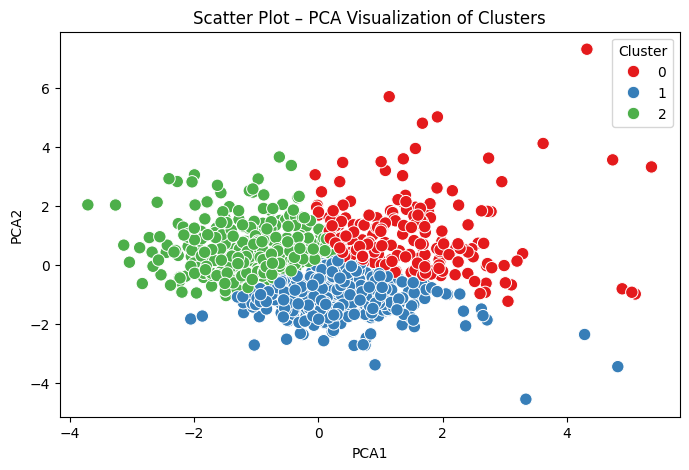

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

#  Run KMeans clustering on the PCA components ---
kmeans = KMeans(n_clusters=3, random_state=42)  # change n_clusters as needed
df['Cluster'] = kmeans.fit_predict(df[['PCA1', 'PCA2']])

#  Plot PCA scatter plot with clusters 
plt.figure(figsize=(8,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1', s=80)
plt.title("Scatter Plot – PCA Visualization of Clusters")
plt.show()

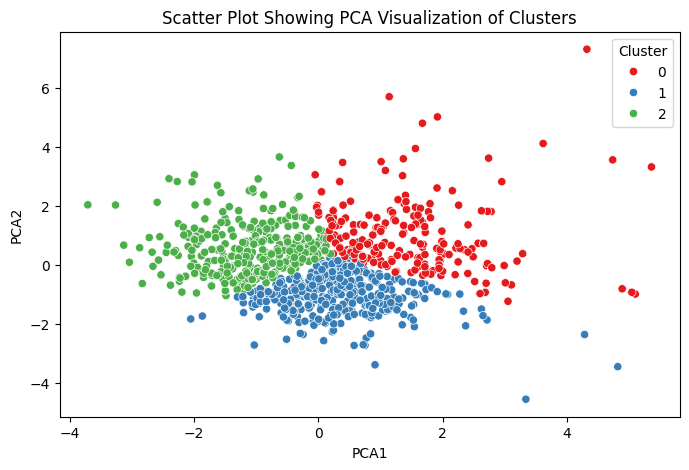

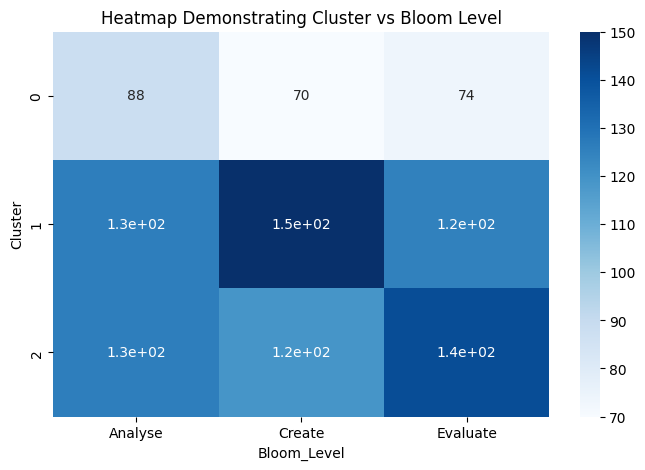

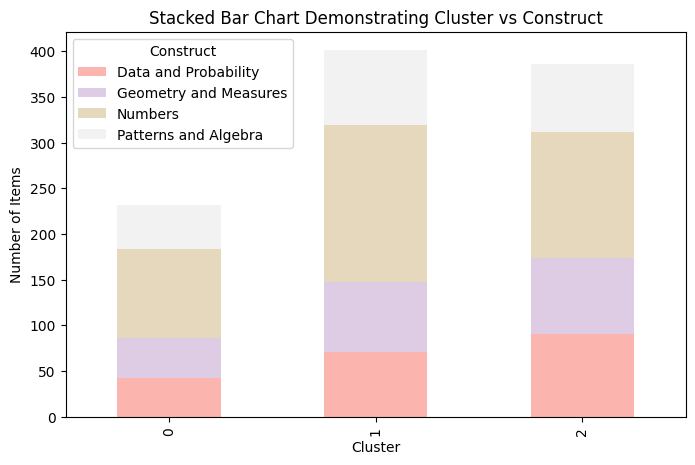

C:\Users\nanyu\AppData\Local\Temp\ipykernel_17216\3868229891.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Lexical Diversity', data=df, palette='Set3')


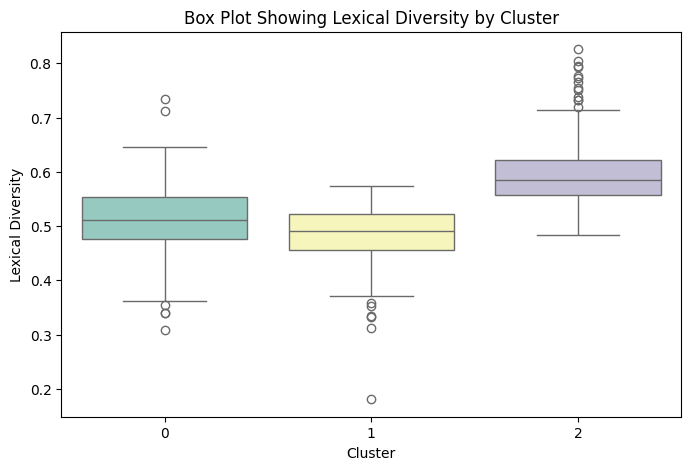

C:\Users\nanyu\AppData\Local\Temp\ipykernel_17216\3868229891.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='Avg Sentence Length', data=df, palette='Set2')


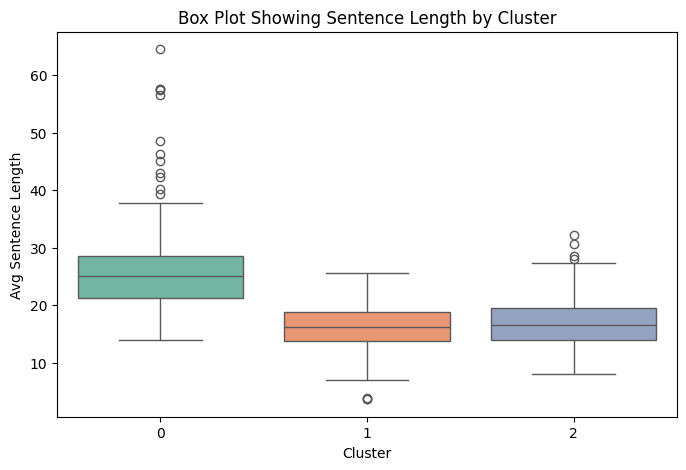

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)
df['PCA1'] = pca_features[:,0]
df['PCA2'] = pca_features[:,1]

plt.figure(figsize=(8,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title("Scatter Plot Showing PCA Visualization of Clusters")
plt.show()

cross = pd.crosstab(df['Cluster'], df['Bloom_Level'])
plt.figure(figsize=(8,5))
sns.heatmap(cross, annot=True, cmap='Blues')
plt.title("Heatmap Demonstrating Cluster vs Bloom Level")
plt.show()


cross = pd.crosstab(df['Cluster'], df['Construct'])
cross.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Pastel1')
plt.title("Stacked Bar Chart Demonstrating Cluster vs Construct")
plt.xlabel("Cluster")
plt.ylabel("Number of Items")
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Lexical Diversity', data=df, palette='Set3')
plt.title("Box Plot Showing Lexical Diversity by Cluster")
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Avg Sentence Length', data=df, palette='Set2')
plt.title("Box Plot Showing Sentence Length by Cluster")
plt.show()

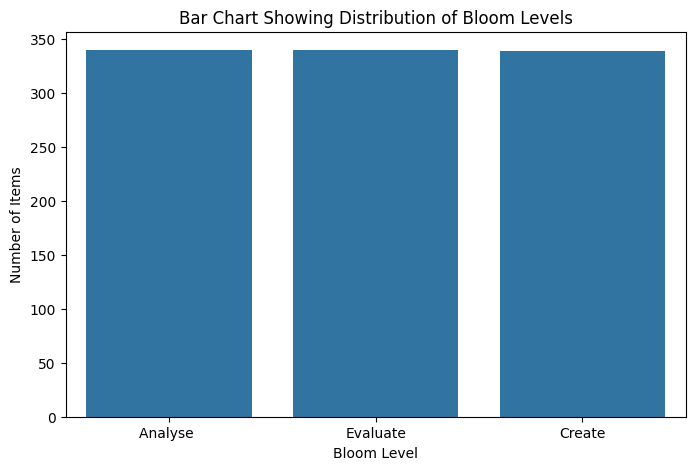

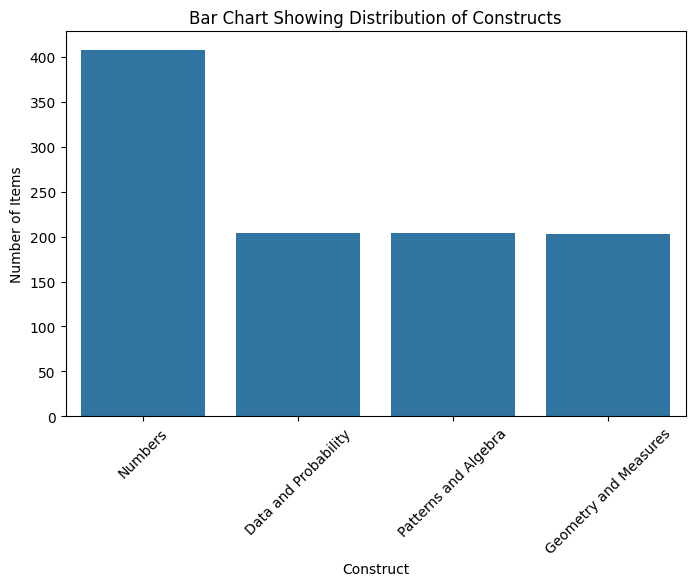

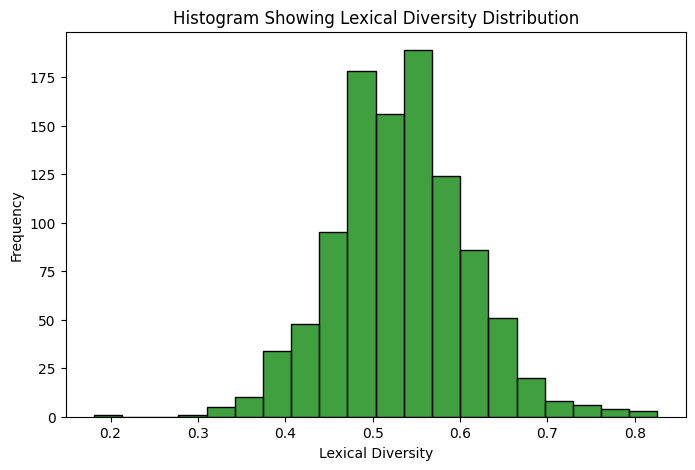

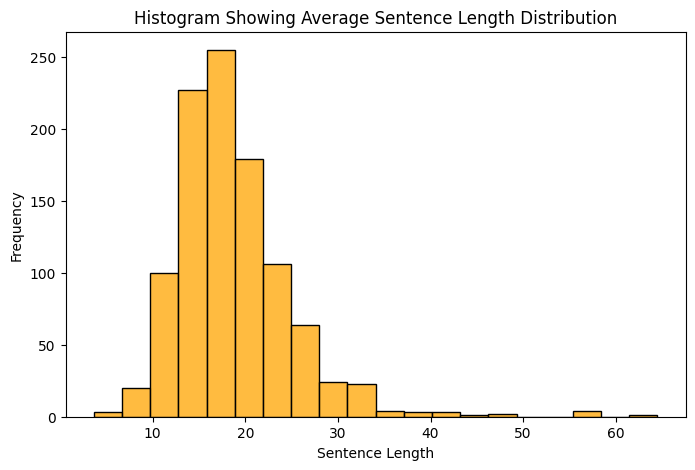

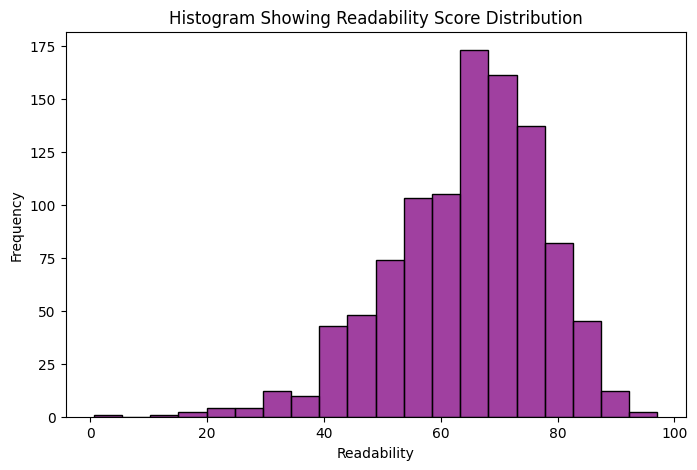

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_excel("ALL_with_features.xlsx")

plt.figure(figsize=(8,5))
sns.countplot(x='Bloom_Level', data=df)
plt.title("Bar Chart Showing Distribution of Bloom Levels")
plt.xlabel("Bloom Level")
plt.ylabel("Number of Items")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='Construct', data=df)
plt.title("Bar Chart Showing Distribution of Constructs")
plt.xlabel("Construct")
plt.ylabel("Number of Items")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Lexical Diversity'], bins=20, color='green')
plt.title("Histogram Showing Lexical Diversity Distribution")
plt.xlabel("Lexical Diversity")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(df['Avg Sentence Length'], bins=20, color='orange')
plt.title("Histogram Showing Average Sentence Length Distribution")
plt.xlabel("Sentence Length")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['Readability'], bins=20, color='purple')
plt.title("Histogram Showing Readability Score Distribution")
plt.xlabel("Readability")
plt.ylabel("Frequency")
plt.show()

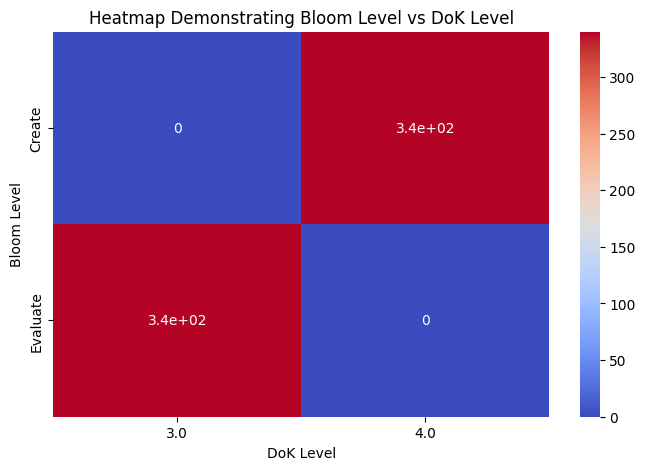

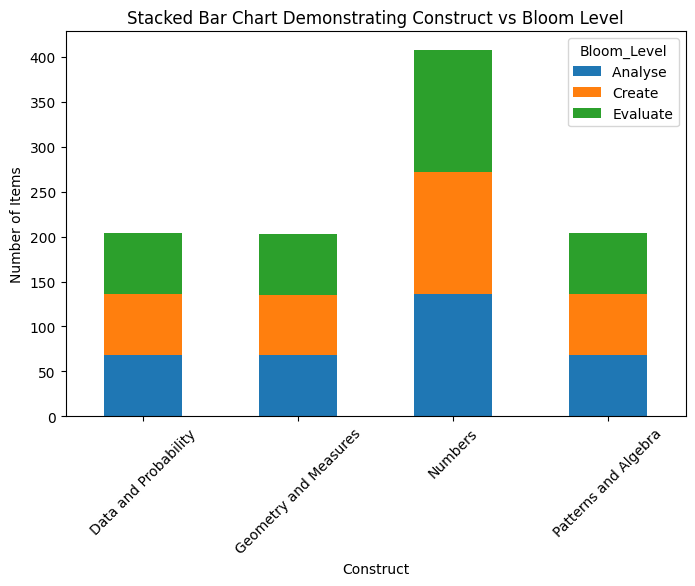

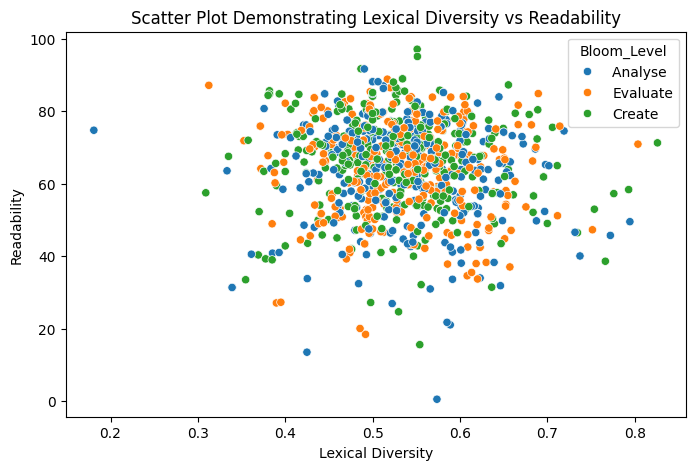

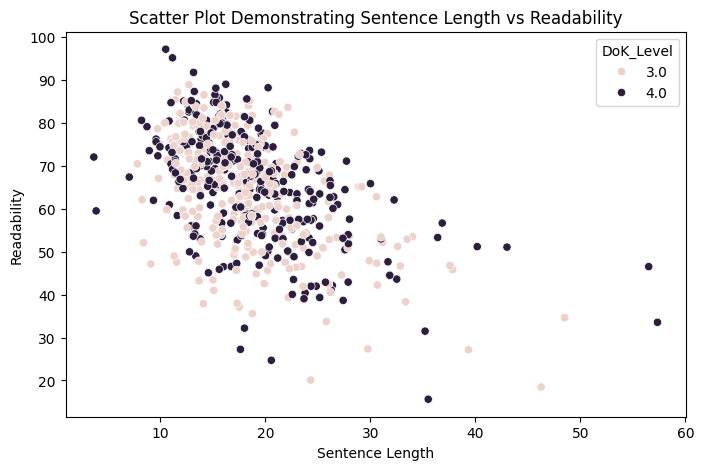

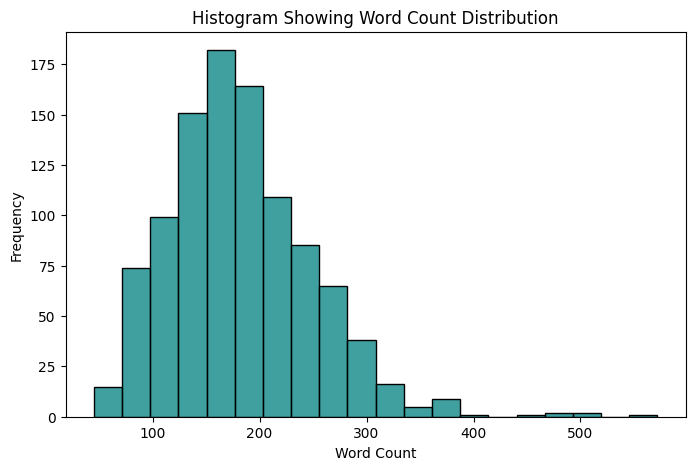

In [46]:

cross = pd.crosstab(df['Bloom_Level'], df['DoK_Level'])
plt.figure(figsize=(8,5))
sns.heatmap(cross, annot=True, cmap='coolwarm')
plt.title("Heatmap Demonstrating Bloom Level vs DoK Level")
plt.xlabel("DoK Level")
plt.ylabel("Bloom Level")
plt.show()

cross = pd.crosstab(df['Construct'], df['Bloom_Level'])
cross.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Stacked Bar Chart Demonstrating Construct vs Bloom Level")
plt.xlabel("Construct")
plt.ylabel("Number of Items")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Lexical Diversity', y='Readability', data=df, hue='Bloom_Level')
plt.title("Scatter Plot Demonstrating Lexical Diversity vs Readability")
plt.xlabel("Lexical Diversity")
plt.ylabel("Readability")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='Avg Sentence Length', y='Readability', data=df, hue='DoK_Level')
plt.title("Scatter Plot Demonstrating Sentence Length vs Readability")
plt.xlabel("Sentence Length")
plt.ylabel("Readability")
plt.show()

df['Word_Count'] = df['Item'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
sns.histplot(df['Word_Count'], bins=20, color='teal')
plt.title("Histogram Showing Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

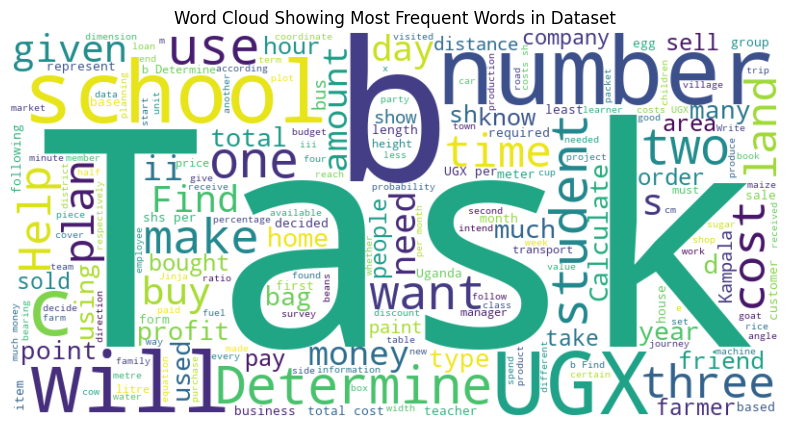

C:\Users\nanyu\AppData\Local\Temp\ipykernel_17216\1166327601.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='word', data=top, palette='viridis')


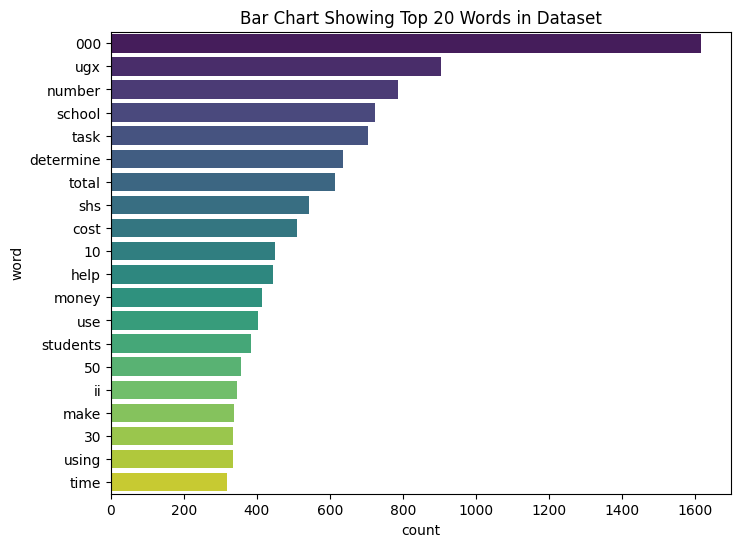

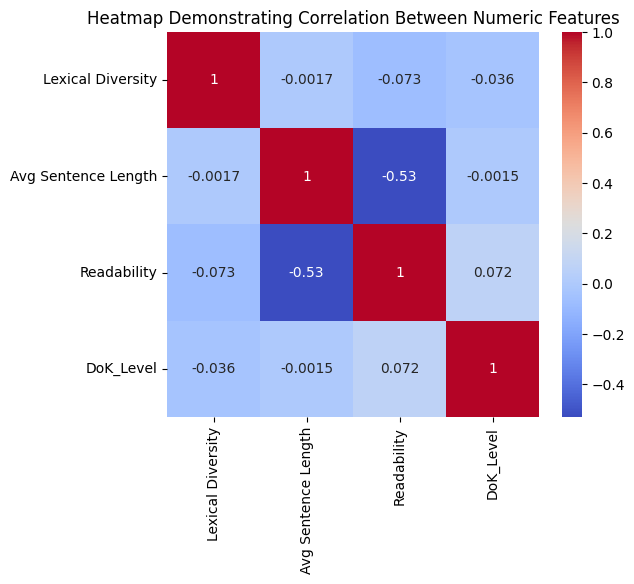

C:\Users\nanyu\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\nanyu\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\nanyu\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\nanyu\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warni

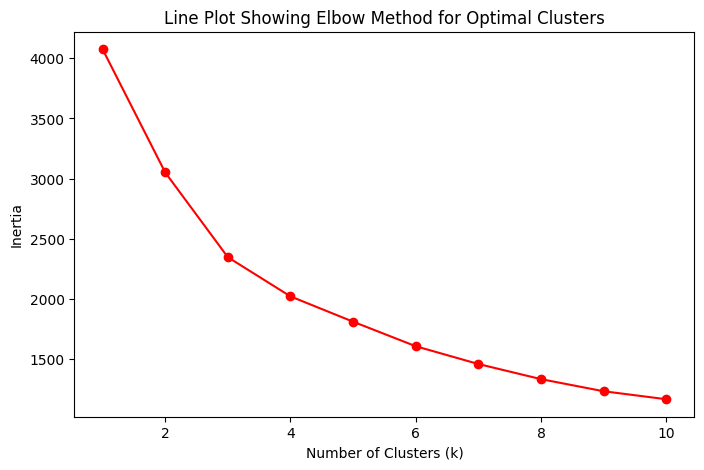

C:\Users\nanyu\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\nanyu\AppData\Local\Temp\ipykernel_17216\1166327601.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Cluster', data=df, palette='Set2')


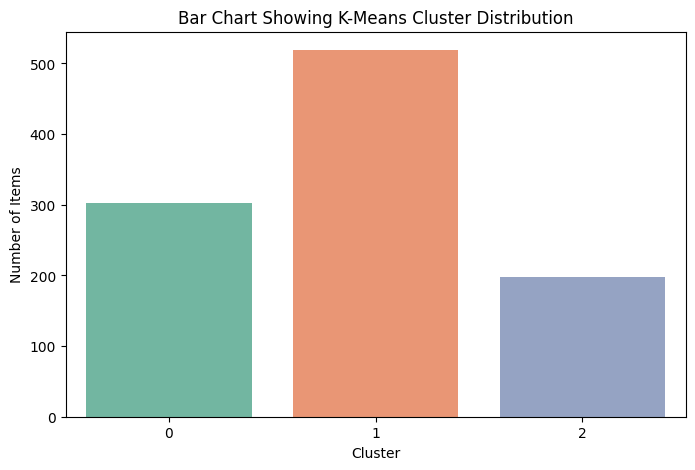

In [73]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

text = " ".join(df['Item'])
wc = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud Showing Most Frequent Words in Dataset")
plt.show()

vec = CountVectorizer(stop_words='english')
X = vec.fit_transform(df['Item'])
counts = X.sum(axis=0).A1
words = vec.get_feature_names_out()
top = pd.DataFrame({'word':words,'count':counts}).sort_values(by='count',ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(x='count', y='word', data=top, palette='viridis')
plt.title("Bar Chart Showing Top 20 Words in Dataset")
plt.show()


plt.figure(figsize=(6,5))
sns.heatmap(df[['Lexical Diversity','Avg Sentence Length','Readability','DoK_Level']].corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Demonstrating Correlation Between Numeric Features")
plt.show()

features = df[['DoK_Level','Lexical Diversity','Avg Sentence Length','Readability']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o', color='red')
plt.title("Line Plot Showing Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_features)

plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=df, palette='Set2')
plt.title("Bar Chart Showing K-Means Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Items")
plt.show()

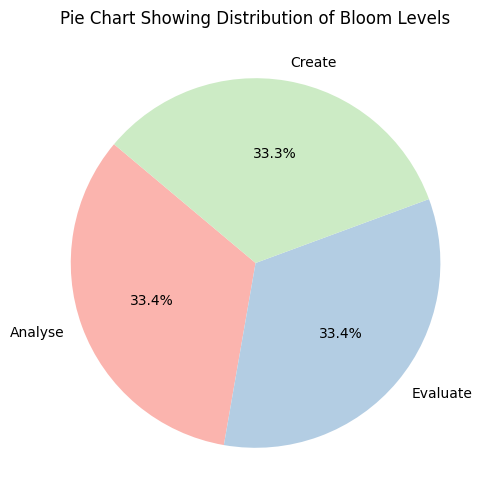

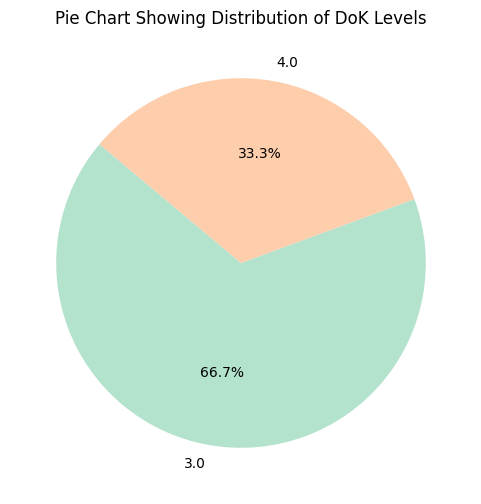

In [76]:
import matplotlib.pyplot as plt

bloom_counts = df['Bloom_Level'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(bloom_counts, labels=bloom_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel1.colors)
plt.title("Pie Chart Showing Distribution of Bloom Levels")
plt.show()

dok_counts = df['DoK_Level'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(dok_counts, labels=dok_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Pastel2.colors)
plt.title("Pie Chart Showing Distribution of DoK Levels")
plt.show()